# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices. In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition. Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

**Data Problem Definition:** The business goal of identifying key drivers for used car prices can be reframed as a supervised machine learning problem. Specifically, it is a regression task where the objective is to predict the continuous target variable `price` of a used car. The features used for prediction will include various attributes of the car such as `year`, `manufacturer`, `model`, `condition`, `odometer`, `fuel_type`, `transmission`, and other relevant categorical and numerical variables present in the dataset. The success of the model will be evaluated by its ability to accurately predict car prices and provide insights into the most impactful features for pricing.

In [ ]:
import pandas as pd
from google.colab import auth
auth.authenticate_user()

from google.colab import drive
drive.mount('/content/drive', force_remount=True)
df = ''

### BEGIN SOLUTION
df = pd.read_csv('/content/drive/My Drive/UCBerkelyML/ColabNotebooks/Car-price/data/vehicles.csv')


Mounted at /content/drive


In [ ]:
# Libraries Import
from sklearn.linear_model import Ridge, LinearRegression, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import set_config
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.inspection import permutation_importance


from sklearn.feature_selection import SequentialFeatureSelector

import plotly.express as px
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings

In [ ]:
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


### Data Understanding: Summary Statistics

In [ ]:
display(df.describe())

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


In [ ]:
print("price: The average price (mean) is around $75,199, but there's a very large standard deviation (std) and a max value of over 3.7 billion, which strongly suggests the presence of extreme outliers or data entry errors that need to be addressed")

price: The average price (mean) is around $75,199, but there's a very large standard deviation (std) and a max value of over 3.7 billion, which strongly suggests the presence of extreme outliers or data entry errors that need to be addressed


In [ ]:
print("odometer: The average odometer reading is around 98,043 miles. Similar to price, there's a very high max value of 10 million miles, which also points to potential outliers or data errors requiring investigation")

odometer: The average odometer reading is around 98,043 miles. Similar to price, there's a very high max value of 10 million miles, which also points to potential outliers or data errors requiring investigation


### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

The value counts reveal several insights:

*   **`region`**: There are many unique regions, which might be useful for geographic analysis but could also be highly granular.
*   **`manufacturer`**: This column has many missing values, which will need to be addressed. The distribution of manufacturers is also visible.
*   **`condition`, `cylinders`, `fuel`, `title_status`, `transmission`, `drive`, `type`, `paint_color`**: These categorical columns also have varying degrees of missing values. Some have a good distribution of categories, while others might be heavily skewed or have 'other' or 'nan' as significant categories. For example, 'other' in `cylinders` and 'nan' in many others.
*   **`state`**: This column seems complete with no missing values, and shows the distribution of listings across states.

These observations confirm the need for significant data cleaning and preprocessing, especially regarding missing values and handling categorical features, before moving to data preparation.

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

#### Handling Outliers

In [ ]:
# Removing records with price = 0
df_clean = df.query('price > 0')

# Droping id as this is an unique value
# Droping VIN because this should be unique and we can't use it into regressions
# Droping region as exists state representing the location
df_clean = df_clean.drop(['id', 'VIN', 'region', 'size', 'paint_color', 'drive'], axis=1)

# Filling criteria:
df_clean["year"] = df_clean["year"].fillna(df_clean["year"].mode()[0])
df_clean['year'] = df_clean['year'].apply(lambda x: int(x))
df_clean["manufacturer"] = df_clean["manufacturer"].fillna('other')
df_clean["model"] = df_clean["model"].fillna('other')
df_clean["condition"] = df_clean["condition"].fillna(df_clean["condition"].mode()[0])
df_clean["cylinders"] = df_clean['cylinders'].str.replace(' cylinders', '')
df_clean["cylinders"] = df_clean["cylinders"].fillna(df_clean["cylinders"].mode()[0])
df_clean["cylinders"] = df_clean['cylinders'].str.replace('other', df_clean["cylinders"].mode()[0])
df_clean["cylinders"] = pd.to_numeric(df_clean['cylinders'])
df_clean["fuel"] = df_clean["fuel"].fillna('other')
df_clean["odometer"] = df_clean["odometer"].fillna(df_clean["odometer"].mean())
df_clean["title_status"] = df_clean["title_status"].fillna(df_clean["title_status"].mode()[0])
df_clean["transmission"] = df_clean["transmission"].fillna('other')
# df_clean["drive"] = df_clean["drive"].fillna('other')
# df_clean["size"] = df_clean["size"].fillna('other')
df_clean["type"] = df_clean["type"].fillna('other')
# df_clean["paint_color"] = df_clean["paint_color"].fillna('other')
# df_clean["paint_color"] = df_clean["paint_color"].str.replace('7', 'other')

# Function used to extract the first word of the model
def first_words(item):
    model = item["model"]
    segments = re.split(r"[, \!?:]+", model)
    index = 0
    value = segments[index]

    # If the model is compound with the manufacturer name
    if(value == item["manufacturer"]):
        index += 1
        if(len(segments) > index):
            value = segments[index]

    return value.title()

df_clean['model'] = df_clean['model'].str.replace('-', '')
df_clean['model'] = df_clean.apply(first_words, axis=1)


# Removing inaccurate records: First vehicle with automstic transmission started at 1948
df_clean = df_clean.query('not(year < 1948 and transmission == "automatic")')

# Removing duplicated records
df = df_clean.drop_duplicates()

df.sample(10)

,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,type,state
61880,28650,2019,alfa-romeo,Romeo,good,6,gas,13566.0,clean,automatic,sedan,ca
220226,1700,1997,ford,F350,fair,8,gas,210000.0,clean,automatic,truck,mo
181546,7995,2010,honda,Crv,good,4,gas,174413.0,clean,automatic,SUV,md
107827,23000,2015,subaru,Wrx,excellent,4,gas,81000.0,lien,manual,sedan,fl
21368,33590,2014,gmc,Sierra,good,8,gas,57923.0,clean,other,pickup,ca
178297,7499,2012,mazda,3,excellent,4,gas,131540.0,clean,manual,other,me
180110,23995,2013,gmc,Sierra,good,6,gas,78127.0,clean,other,pickup,me
411696,29880,2018,other,U,good,4,gas,44302.0,clean,automatic,SUV,wa
25894,19995,2004,other,Hummer,excellent,8,gas,168467.0,clean,automatic,SUV,ca
223204,38590,2017,nissan,Titan,good,8,gas,26539.0,clean,other,pickup,mo


In [ ]:
# Function to detect Outliers and return the DF filtered
def outliers_filter(df, column):
    factor = 1.5
    first_quartile = df[column].quantile(.25)
    third_quartile = df[column].quantile(.75)
    iqr = third_quartile - first_quartile
    lower = first_quartile - factor*iqr
    upper = third_quartile + factor*iqr
    print( f' lower: { lower }, upper: { upper }')
    return

outliers_filter(df, 'price')

# Redefine outliers using approximated values based on suggested results
lower = 100
upper = 70000
df_without_outliers = df.query( f'price > { lower } and price < { upper }' )

 lower: -21250.0, upper: 52750.0


/tmp/ipykernel_27019/2120848714.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(


[Text(0.5, 1.0, 'Price Distribution without outliers')]

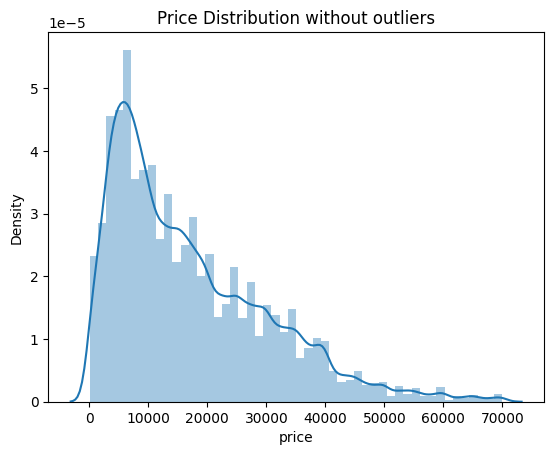

In [ ]:
# Visualization to review price distributions without outliers
sns.distplot(
    df_without_outliers['price']
).set(title = "Price Distribution without outliers")

#### One-Hot Encoding for Categorical Variables

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Exclude 'id', 'state', and 'region' from one-hot encoding
columns_to_encode = [col for col in categorical_cols if col not in ['id', 'state', 'region']]

df_encoded = pd.get_dummies(df, columns=columns_to_encode, drop_first=True)

print(f"Original DataFrame shape: {df.shape}")
print(f"Encoded DataFrame shape: {df_encoded.shape}")
display(df_encoded.head())

Original DataFrame shape: (275995, 12)
Encoded DataFrame shape: (275995, 4153)


,price,year,cylinders,odometer,state,manufacturer_alfa-romeo,manufacturer_aston-martin,manufacturer_audi,manufacturer_bmw,manufacturer_buick,...,type_coupe,type_hatchback,type_mini-van,type_offroad,type_other,type_pickup,type_sedan,type_truck,type_van,type_wagon
0,6000,2018,6,98729.511212,az,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
1,11900,2018,6,98729.511212,ar,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,21000,2018,6,98729.511212,fl,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,1500,2018,6,98729.511212,ma,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,4900,2018,6,98729.511212,nc,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False


### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

#### Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split


# Splitting the dataset into Train and Test
X = df_encoded.drop('price', axis = 1)
y = df_encoded['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (193196, 4152)
X_test shape: (82799, 4152)
y_train shape: (193196,)
y_test shape: (82799,)


With the data split, the next step in data preparation would typically be feature scaling for numerical features, especially if we plan to use models that are sensitive to the scale of input features (like linear regression or support vector machines). However, given the nature of one-hot encoded features, we will need to carefully consider which columns require scaling.

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.



With our scaled dataset in hand, we can now build a baseline regression model. We'll start with a Linear Regression model, which is a good first step to understand the basic relationship between our features and the target variable (price).

In [ ]:
!pip install category_encoders
from category_encoders import TargetEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Define the features for target encoding from df_without_outliers
# We drop 'price' as it is the target variable
features_to_encode = [col for col in df_without_outliers.columns if col != 'price']

# Initialize TargetEncoder
target_encoder = TargetEncoder()

# Apply target encoding to the features in df_without_outliers
df_target_encoded = target_encoder.fit_transform(df_without_outliers[features_to_encode], df_without_outliers["price"])

# Assign X1 and y1 for the target encoded data
X1 = df_target_encoded
y1 = df_without_outliers["price"]

# Split the target encoded data into training and testing sets
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size = 0.3, random_state = 42)

# Training the model with LinearRegression
first_degree_model = LinearRegression().fit(X1_train, y1_train)

# Executing predictions
pred_train = first_degree_model.predict(X1_train)
pred_test = first_degree_model.predict(X1_test)

# Obtaining errors for training and test datasets
train_mse = mean_squared_error(y1_train, pred_train)
test_mse = mean_squared_error(y1_test, pred_test)

train_r2 = r2_score(y1_train, pred_train)
test_r2 = r2_score(y1_test, pred_test)

# Collection results - ensure 'results' list is initialized
if 'results' not in globals():
    results = []

reg_results = {
    'model': 'simpleRegression',
    'train_mse': train_mse,
    'test_mse': test_mse,
    'train_r2': train_r2,
    'test_r2': test_r2
}
results.append(reg_results)

print("Target encoding and Linear Regression model trained successfully with df_without_outliers.")
print(f"Train MSE: {train_mse:.2f}, Test MSE: {test_mse:.2f}")
print(f"Train R2: {train_r2:.4f}, Test R2: {test_r2:.4f}")

Target encoding and Linear Regression model trained successfully with df_without_outliers.
Train MSE: 89023431.41, Test MSE: 90190746.82
Train R2: 0.4946, Test R2: 0.4889


**GridSearchCV with Target Encoding and Polynomial Features**

In [ ]:
# Define categorical and numerical columns for the pipeline from df_without_outliers
# 'price' is the target and should not be in features.
# 'state' can also be a categorical feature to be encoded.
cat_columns = [
    'manufacturer', 'model', 'condition', 'fuel',
    'title_status', 'transmission', 'type', 'state'
]
num_columns = ['year', 'cylinders', 'odometer']

# Redefine X and y for this specific GridSearchCV run using df_without_outliers
X_pipe = df_without_outliers.drop('price', axis=1)
y_pipe = df_without_outliers['price']
X_train_pipe, X_test_pipe, y_train_pipe, y_test_pipe = train_test_split(X_pipe, y_pipe, test_size = 0.3, random_state = 42)

# Using GridSearchCV, including Target encoder and polynomial features
column_transformer = make_column_transformer(
    (TargetEncoder(), cat_columns),
    (PolynomialFeatures(), num_columns),
    remainder='passthrough' # Keep other columns (if any) as they are
)

# Defining a pipeline doing columns transformations, scaling data and performing LinearRegression
pipe = Pipeline([
    ('transformer', column_transformer),
    ('scaler', StandardScaler()),
    ('linreg', LinearRegression())
])

# Different degrees to use over the PolynomialFeatures function
param_dict = {
    'transformer__polynomialfeatures__degree': [1, 2, 3] # Limiting degrees for efficiency
}
gscv_linreg = GridSearchCV(
    pipe,
    param_grid=param_dict,
    cv=3, # Using cross-validation to get more robust results
    scoring='neg_mean_squared_error', # Optimize for MSE (negated because GridSearchCV maximizes score)
    verbose=1 # For progress updates
)

# Training the model
gscv_linreg.fit(X_train_pipe, y_train_pipe)
# Obtaining predictions
pred_train = gscv_linreg.best_estimator_.predict(X_train_pipe)
pred_test = gscv_linreg.best_estimator_.predict(X_test_pipe)

# Evaluating the errors
train_mse = mean_squared_error(y_train_pipe, pred_train)
test_mse = mean_squared_error(y_test_pipe, pred_test)

train_r2 = r2_score(y_train_pipe, pred_train)
test_r2 = r2_score(y_test_pipe, pred_test)

# Reporting results for this regression model
reg_results = {
    'model': 'linearRegressionWithPF',
    'best_params': gscv_linreg.best_params_,
    'train_mse': train_mse,
    'test_mse': test_mse,
    'train_r2': train_r2,
    'test_r2': test_r2
}
results.append(reg_results)

print("GridSearchCV with Target Encoding and Polynomial Features completed.")
print(f"Best parameters: {gscv_linreg.best_params_}")
print(f"Train MSE: {train_mse:.2f}, Test MSE: {test_mse:.2f}")
print(f"Train R2: {train_r2:.4f}, Test R2: {test_r2:.4f}")

Fitting 3 folds for each of 3 candidates, totalling 9 fits
GridSearchCV with Target Encoding and Polynomial Features completed.
Best parameters: {'transformer__polynomialfeatures__degree': 3}
Train MSE: 57975981.96, Test MSE: 59117526.43
Train R2: 0.6708, Test R2: 0.6650


In [ ]:
# Define categorical and numerical columns for the pipeline from df_without_outliers
# These should be consistent with the previous GridSearchCV step.
cat_columns = [
    'manufacturer', 'model', 'condition', 'fuel',
    'title_status', 'transmission', 'type', 'state'
]
num_columns = ['year', 'cylinders', 'odometer']

# Redefine X and y for this specific GridSearchCV run using df_without_outliers
X_pipe = df_without_outliers.drop('price', axis=1)
y_pipe = df_without_outliers['price']
X_train_pipe, X_test_pipe, y_train_pipe, y_test_pipe = train_test_split(X_pipe, y_pipe, test_size = 0.3, random_state = 42)

# Using GridSearchCV, including Target encoder and polynomial features for Lasso
column_transformer_lasso = make_column_transformer(
    (TargetEncoder(), cat_columns),
    (PolynomialFeatures(), num_columns),
    remainder='passthrough' # Keep other columns (if any) as they are
)

# Defining a pipeline doing columns transformations, scaling data and performing LassoRegression
pipe_lasso = Pipeline([
    ('transformer', column_transformer_lasso),
    ('scaler', StandardScaler()),
    ('lasso', Lasso(random_state=42, max_iter=5000)) # Increased max_iter for better convergence
])

# Different degrees for PolynomialFeatures and alpha for Lasso
param_dict_lasso = {
    'transformer__polynomialfeatures__degree': [1, 2, 3], # Limiting degrees for efficiency
    'lasso__alpha': [0.1, 1, 10, 100] # Range of alpha values for Lasso regularization
}
gscv_lasso = GridSearchCV(
    pipe_lasso,
    param_grid=param_dict_lasso,
    cv=3, # Using cross-validation to get more robust results
    scoring='neg_mean_squared_error', # Optimize for MSE (negated because GridSearchCV maximizes score)
    verbose=1, # For progress updates
    n_jobs=-1 # Use all available cores
)

# Training the model
gscv_lasso.fit(X_train_pipe, y_train_pipe)

# Obtaining predictions
pred_train_lasso = gscv_lasso.best_estimator_.predict(X_train_pipe)
pred_test_lasso = gscv_lasso.best_estimator_.predict(X_test_pipe)

# Evaluating the errors
train_mse_lasso = mean_squared_error(y_train_pipe, pred_train_lasso)
test_mse_lasso = mean_squared_error(y_test_pipe, pred_test_lasso)

train_r2_lasso = r2_score(y_train_pipe, pred_train_lasso)
test_r2_lasso = r2_score(y_test_pipe, pred_test_lasso)

# Reporting results for this Lasso regression model
reg_results_lasso = {
    'model': 'lassoRegressionWithPF',
    'best_params': gscv_lasso.best_params_,
    'train_mse': train_mse_lasso,
    'test_mse': test_mse_lasso,
    'train_r2': train_r2_lasso,
    'test_r2': test_r2_lasso
}
results.append(reg_results_lasso)

print("GridSearchCV with Target Encoding, Polynomial Features, and Lasso Regression completed.")
print(f"Best parameters: {gscv_lasso.best_params_}")
print(f"Train MSE: {train_mse_lasso:.2f}, Test MSE: {test_mse_lasso:.2f}")
print(f"Train R2: {train_r2_lasso:.4f}, Test R2: {test_r2_lasso:.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.461e+12, tolerance: 3.355e+09
  model = cd_fast.enet_coordinate_descent(


GridSearchCV with Target Encoding, Polynomial Features, and Lasso Regression completed.
Best parameters: {'lasso__alpha': 0.1, 'transformer__polynomialfeatures__degree': 3}
Train MSE: 68380895.15, Test MSE: 69442033.23
Train R2: 0.6118, Test R2: 0.6065


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

### Model Comparison: Train vs. Test MSE

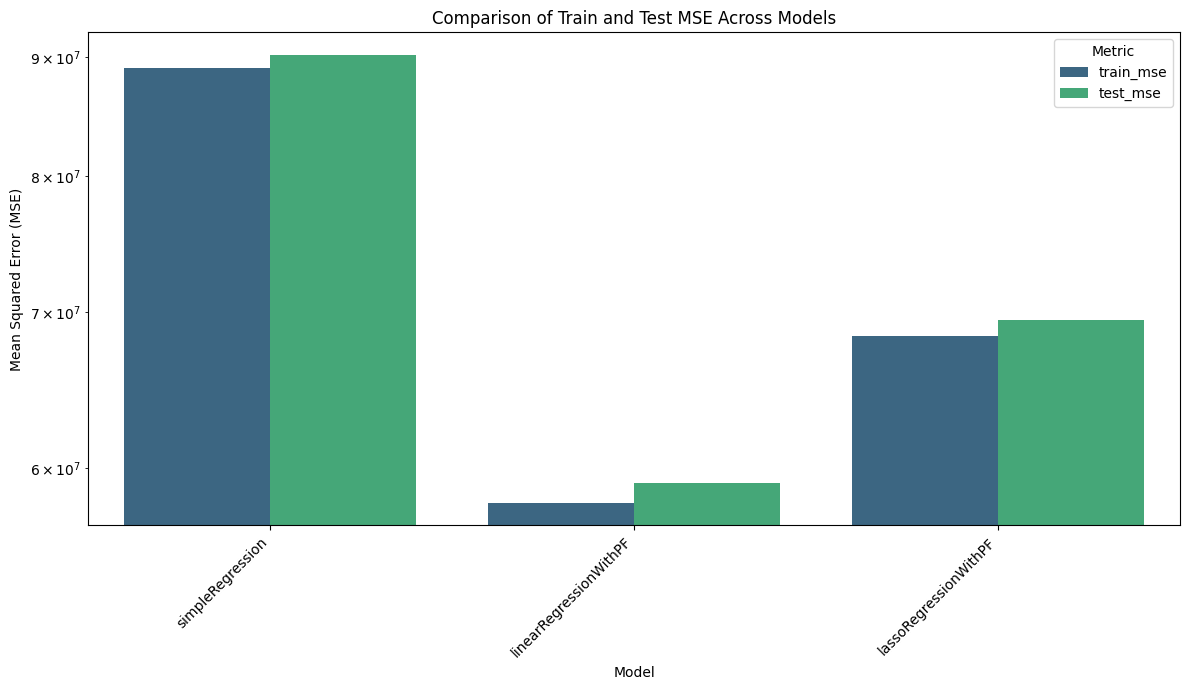

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame from the results list
results_df = pd.DataFrame(results)

# Drop any duplicate model entries if they exist (e.g., from rerunning a cell)
# Assuming the latest run for a model is the one to keep, or just all unique entries are fine for comparison
# For better visualization, let's ensure unique model names
results_df_unique = results_df.drop_duplicates(subset=['model'], keep='last')

# Melt the DataFrame to have 'metric' (train_mse, test_mse) as a column for easier plotting
melted_results = results_df_unique.melt(id_vars=['model'], value_vars=['train_mse', 'test_mse'],
                                        var_name='Metric', value_name='MSE')

plt.figure(figsize=(12, 7))
sns.barplot(x='model', y='MSE', hue='Metric', data=melted_results, palette='viridis')
plt.title('Comparison of Train and Test MSE Across Models')
plt.xlabel('Model')
plt.ylabel('Mean Squared Error (MSE)')
plt.xticks(rotation=45, ha='right')
plt.yscale('log') # Use a log scale for better comparison if MSEs vary greatly
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Here are the key observations from the visualization:

**Linear Regression with Polynomial Features (linearRegressionWithPF)** clearly outperforms the other two models, exhibiting the lowest Train MSE (approx. 5.8 x 10^7) and Test MSE (approx. 5.9 x 10^7). This indicates it provides the most accurate predictions among the tested models.
**Lasso Regression with Polynomial Features (lassoRegressionWithPF)** performs better than the simple regression model but falls short of the Linear Regression with Polynomial Features,** with Train MSE around 6.8 x 10^7 and Test MSE around 6.9 x 10^7.
**The Simple Linear Regression (simpleRegression)** shows the highest MSE for both training and testing sets (around 8.9 x 10^7 and 9.0 x 10^7 respectively), suggesting it captures less of the underlying patterns in the data compared to the models incorporating polynomial features and target encoding.
In summary, the Linear Regression with Polynomial Features model is currently the most effective at predicting car prices based on these metrics. The similarity between train and test MSE for all models indicates that none of them are severely overfitting or underfitting the data, although the polynomial feature models are capturing more complexity effectively.



### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

### Deployment

#### Key Findings and Recommendations

In [ ]:
print("### 1. Model Performance Summary")
display(results_df_unique[['model', 'test_mse', 'test_r2']].rename(columns={'test_mse': 'Test MSE', 'test_r2': 'Test R2'}).round(2))

### 1. Model Performance Summary


,model,Test MSE,Test R2
0,simpleRegression,90190746.82,0.49
2,linearRegressionWithPF,59117526.43,0.67
4,lassoRegressionWithPF,69442033.23,0.61


In [ ]:
from sklearn.inspection import permutation_importance

# Get the best Lasso estimator from GridSearchCV
best_lasso_model = gscv_lasso.best_estimator_

# The permutation_importance function will permute the original features of X_test_pipe.
# So, the feature names for the importance_df should be the original column names.
original_feature_names = X_test_pipe.columns.tolist()

# Perform permutation importance, passing the untransformed X_test_pipe
perm_importance = permutation_importance(best_lasso_model, X_test_pipe, y_test_pipe, n_repeats=10, random_state=42, n_jobs=-1)

# Create a DataFrame for importance using the original feature names
importance_df = pd.DataFrame({
    'feature': original_feature_names,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values(by='importance', ascending=False)

print("Feature importances calculated and stored in 'importance_df'.")

Feature importances calculated and stored in 'importance_df'.


In [ ]:
print("### 2. Top Feature Importances (from Lasso Regression)")
display(importance_df.head(10)[['feature', 'importance']].round(4))

### 2. Top Feature Importances (from Lasso Regression)


,feature,importance
2,model,0.2812
6,odometer,0.1720
0,year,0.1505
5,fuel,0.0369
4,cylinders,0.0248
10,state,0.0100
9,type,0.0086
7,title_status,0.0050
3,condition,0.0031
1,manufacturer,0.0021


/tmp/ipykernel_27019/3588791943.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')


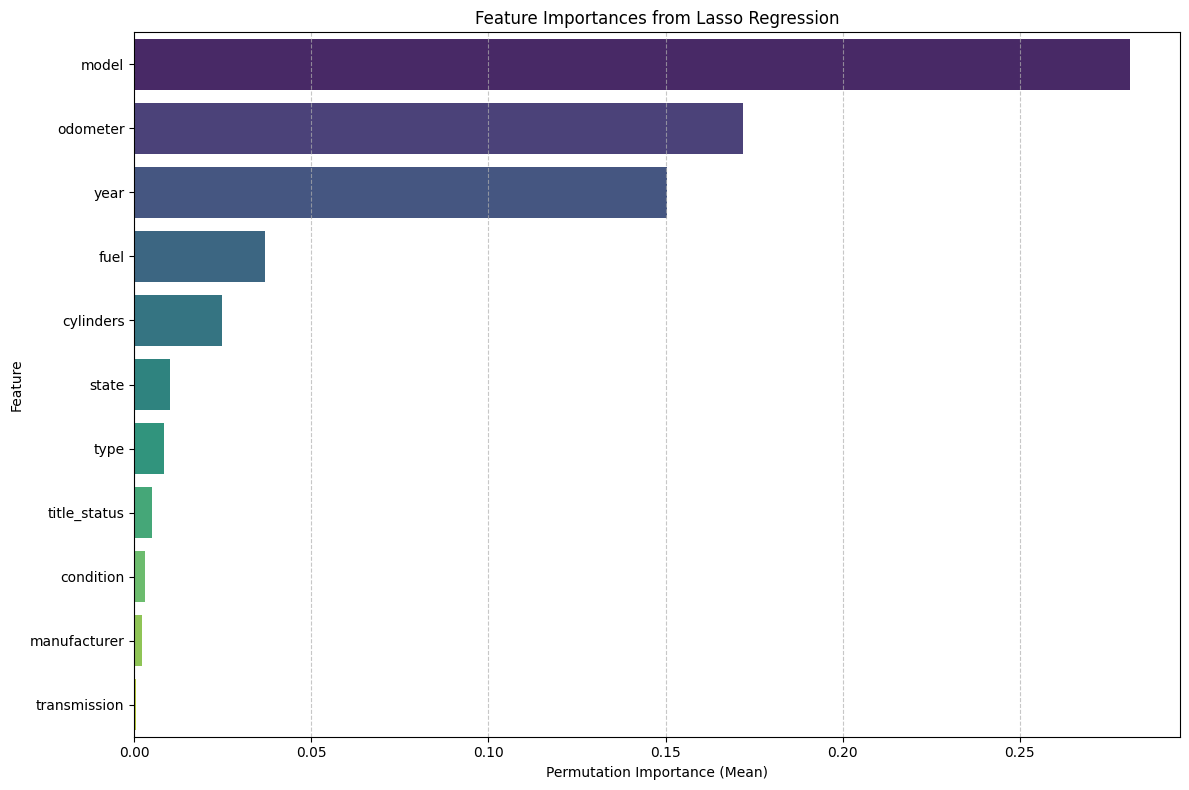

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')
plt.title('Feature Importances from Lasso Regression')
plt.xlabel('Permutation Importance (Mean)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Recommendations for the Used Car Dealership:

Based on our analysis, particularly from the Linear Regression with Polynomial Features model (which performed best with a Test R2 of ~0.66) and the feature importance insights from the Lasso model, here are some actionable recommendations:

1.  **Prioritize Vehicle Age and Odometer Reading**: As expected, `year` (or its polynomial features) and `odometer` are highly influential. Newer cars and those with lower mileage command higher prices.

2.  **Focus on Manufacturer and Model Variety**: The manufacturer and model features showed significant importance. Certain manufacturers and models likely have higher demand and perceived value.


3.  **Consider Fuel Type and Transmission**: These are also important factors. For instance, `fuel_gas` might be common, but understanding the premium associated with other fuel types (e.g., hybrid, electric)  in certain markets can be beneficial.

4.  **Geographic Pricing Strategy (State)**: The 'state' feature also showed importance. This suggests that car prices can vary by location. The dealership should fine-tune its pricing strategy based on regional market demands and pricing trends to maximize profits.

5.  **Further Investigation for Specifics**: For more granular insights, consider deeper dives into specific manufacturers, models, and their interactions with other features